# Laboratori 4 · Ushtrime Shtesë — Grafet: nga Urat e Königsbergut te Komponentet e Lidhura Fort

> **Lidhja me leksionin:** *Leksioni 4 — Grafet* (slides 1–73).
>
> Laboratori kryesor ndërtoi grafe me klikime dhe i vizatoi me NetworkX. Këtu çdo koncept i leksionit
> kthehet në një funksion të vogël Python që e shkruani vetë — me bashkësi (`set`) dhe fjalorë (`dict`),
> pa biblioteka të gatshme. NetworkX përdoret **vetëm** për vizatim.
> Nuk kërkon Pygame.

| # | Ushtrimi | Konceptet e leksionit |
|:-:|---|---|
| 1 | Urat e Königsbergut | multigraf, fuqia e kulmit, Euler |
| 2 | Lema e shtrëngimit të duarve | $\sum \deg(v) = 2\lvert E\rvert$ |
| 3 | Grafe speciale | graf i plotë $K_n$, grafi plotësues, graf i rregullt, kubi $Q_3$ |
| 4 | Nëngrafet | nëngraf, i induktuar, përfshirës, klikë, e pavarur |
| 5 | Paraqitja e grafeve | matrica dhe lista e fqinjësisë; graf, multigraf, digraf; i dendur / i rrallë |
| 6 | Ecje nëpër graf | udhëtim, udha, cikël, shteg, cikël elementar |
| 7 | Largesa, diametri, lidhja | shtegu më i shkurtër, diametri, komponentet e lidhura |
| 8 | Lidhja te digrafet | digraf i lidhur, i lidhur fort, komponentet e lidhura fort |

## Kujtues teorik — Fjalori i leksionit

**Grafi** $G = (V, E)$: bashkësi **kulmesh** $V$ dhe bashkësi **brinjësh** $E$, ku çdo brinjë është një çift
i parenditur kulmesh $\{u, v\}$. Kulmet $u, v$ janë **fqinjë**; brinja $\{u,v\}$ është **incidente** me $u$ dhe $v$.

| Koncepti | Përkufizimi |
|---|---|
| **Fuqia** $\deg(v)$ | numri i brinjëve incidente me $v$ (laku numërohet 2 herë) |
| **Lema e shtrëngimit të duarve** | $\sum_{v \in V} \deg(v) = 2\lvert E\rvert$ |
| **Graf i rregullt** | të gjithë kulmet kanë të njëjtën fuqi $k$ ($k$-i rregullt) |
| **Graf i plotë** $K_n$ | çdo çift kulmesh është brinjë; $\lvert E\rvert = \frac{n(n-1)}{2}$ |
| **Grafi plotësues** $\overline{G}$ | të njëjtat kulme; $\{u,v\}$ është brinjë e $\overline G$ ⟺ nuk është brinjë e $G$ |
| **Nëngraf** $H \subseteq G$ | $V(H) \subseteq V(G)$, $E(H) \subseteq E(G)$ |
| **Nëngraf i induktuar** $G[W]$ | kulmet $W$ dhe **të gjitha** brinjët e $G$ me të dy skajet në $W$ |
| **Nëngraf përfshirës** | nëngraf me **të gjitha** kulmet e $G$ |
| **Klikë** / **e pavarur** | çdo dy kulme janë fqinjë / asnjë dy kulme nuk janë fqinjë |
| **Multigraf** | lejon brinjë paralele dhe lake |
| **Digraf** | çdo **hark** $(u, v)$ ka fillim $u$ dhe mbarim $v$; fuqia dalëse $\deg^+$ dhe hyrëse $\deg^-$ |

### Ecje nëpër graf (slides 57–73)

| Graf | Digraf | Përkufizimi |
|---|---|---|
| **Udhëtim** | **Rrugëtim** | varg kulmesh ku çdo dy të njëpasnjëshëm janë fqinjë |
| **Udha** | — | udhëtim që **nuk përsërit brinjë** |
| **Cikël** | **Cirkuit** | udha (rrugëtim) **e mbyllur** |
| **Shteg** | **Rrugë** | udha që **nuk përsërit kulme** (përveç skajeve) |
| **Cikël elementar** | **Cirkuit elementar** | shteg (rrugë) i mbyllur |

**Largesa** $d(u,v)$ = gjatësia e shtegut më të shkurtër; **diametri** = $\max_{u,v} d(u,v)$.
Një **komponente e lidhur** është nëngraf i lidhur **maksimal**. Një digraf është **i lidhur** nëse grafi
që merret duke harruar drejtimet është i lidhur, dhe **i lidhur fort** nëse çdo kulm arrin çdo kulm tjetër.

In [1]:
# ── Mjeti i kontrollit ──────────────────────────────────────────────
# Ekzekutojeni këtë qelizë një herë, në fillim. Pas çdo ushtrimi, qeliza
# "kontrollo(...)" teston funksionin tuaj dhe ju tregon nëse është gati.

def kontrollo(titulli, testet):
    try:
        testet()
    except NotImplementedError:
        print(f"⏳ {titulli}: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.")
    except AssertionError as e:
        print(f"✗ {titulli}: {e}")
    except Exception as e:
        print(f"✗ {titulli}: kodi u ndal me gabim  {type(e).__name__}: {e}")
    else:
        print(f"✓ {titulli}: të gjitha testet kaluan!")


# ── Paraqitja që përdorim në gjithë fletoren ────────────────────────
#   V = {"a", "b", "c"}                       bashkësia e kulmeve
#   E = [("a", "b"), ("b", "c")]              lista e brinjëve (lejon edhe brinjë paralele)
# Për grafe të thjeshta, një brinjë {u, v} krahasohet pa rend: frozenset({u, v}).

def brinje(u, v):
    return frozenset((u, v))

## Ushtrimi 1 — Urat e Königsbergut (slides 2–3, 42)

Lumi Pregel ndan qytetin në 4 pjesë: ishulli **A** (Kneiphof), brigjet **B**, **C** dhe pjesa lindore **D**.
Shtatë urat janë brinjë — dhe midis A–B, A–C ka nga **dy** ura. Pra ky është një **multigraf**.

Euler vuri re: një shëtitje që kalon **çdo urë saktësisht një herë** (një udha që përdor të gjitha brinjët)
ekziston në një multigraf të lidhur **atëherë dhe vetëm atëherë** kur numri i kulmeve me fuqi tek është **0 ose 2**.

**Detyra:**
1. `fuqite(V, E)` — fjalor `{kulm: fuqia}` për një multigraf të dhënë si listë brinjësh. Laku `(v, v)` shton 2.
2. `ka_udhe_euleri(V, E)` — `True` nëse numri i kulmeve me fuqi tek është 0 ose 2 (supozojmë grafin të lidhur).

In [2]:
V_konigsberg = {"A", "B", "C", "D"}
E_konigsberg = [("A", "B"), ("A", "B"), ("A", "C"), ("A", "C"), ("A", "D"), ("B", "D"), ("C", "D")]


def fuqite(V, E):
    # PLOTESO: nisni me 0 për çdo kulm; çdo brinjë (u, v) i shton 1 secilit skaj
    raise NotImplementedError


def ka_udhe_euleri(V, E):
    # PLOTESO
    raise NotImplementedError

In [3]:
def _testet():
    assert fuqite(V_konigsberg, E_konigsberg) == {"A": 5, "B": 3, "C": 3, "D": 3}, \
        f"fuqitë e Königsbergut janë A:5, B:3, C:3, D:3 — ju morët {fuqite(V_konigsberg, E_konigsberg)}"
    assert fuqite({"x"}, [("x", "x")]) == {"x": 2}, "laku (x, x) i shton 2 fuqisë së x"
    assert fuqite({"a", "b", "c"}, []) == {"a": 0, "b": 0, "c": 0}, "kulmet e izoluar kanë fuqi 0"
    assert ka_udhe_euleri(V_konigsberg, E_konigsberg) is False, "Königsberg: 4 kulme me fuqi tek → NUK ka"
    assert ka_udhe_euleri(V_konigsberg, E_konigsberg + [("B", "C")]) is True, \
        "me një urë të tetë B–C mbeten vetëm A dhe D me fuqi tek → ka"
    assert ka_udhe_euleri({"a", "b", "c"}, [("a", "b"), ("b", "c"), ("c", "a")]) is True, "trekëndëshi: 0 kulme tek"

kontrollo("Ushtrimi 1 — Königsberg", _testet)

⏳ Ushtrimi 1 — Königsberg: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


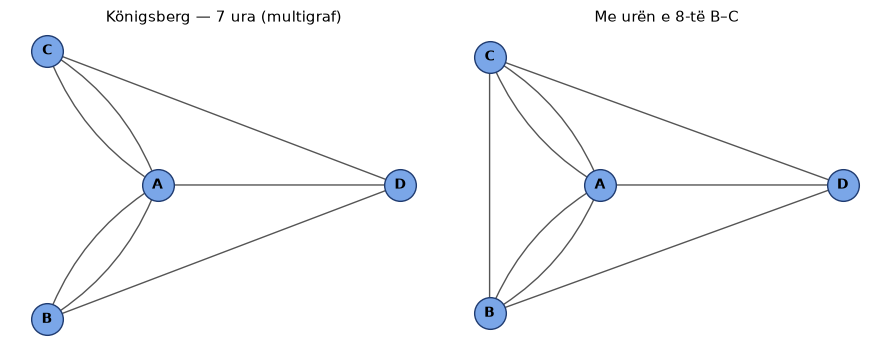

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def vizato(V, E, titulli="", ax=None, drejtuar=False, ngjyra=None, pos=None):
    # Vizaton një graf / multigraf / digraf me NetworkX. Përdoret vetëm për figurë.
    G = (nx.MultiDiGraph if drejtuar else nx.MultiGraph)()
    G.add_nodes_from(sorted(V))
    G.add_edges_from(E)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3.4))
    pos = pos or nx.circular_layout(sorted(V))
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=ngjyra or "#7aa6e8", node_size=520, edgecolors="#1f3b70")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")
    # brinjët paralele hapen në mënyrë simetrike; harqet e kundërta u → v, v → u përkulen
    celes = (lambda u, v: (u, v)) if drejtuar else (lambda u, v: tuple(sorted((u, v))))
    gjithsej, pare = {}, {}
    for u, v in E:
        gjithsej[celes(u, v)] = gjithsej.get(celes(u, v), 0) + 1
    for u, v in E:
        k = celes(u, v)
        r = pare.get(k, 0); pare[k] = r + 1
        rad = 0.35 * (r - (gjithsej[k] - 1) / 2)
        if drejtuar and (v, u) in gjithsej:
            rad += 0.2
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax, arrows=True, arrowsize=14,
                               arrowstyle="-|>" if drejtuar else "-", node_size=520,
                               connectionstyle=f"arc3,rad={rad}", edge_color="#555")
    ax.set_title(titulli, fontsize=11)
    ax.axis("off")
    return ax

pos_k = {"C": (0, 1), "A": (0.5, 0), "B": (0, -1), "D": (1.6, 0)}
fig, axs = plt.subplots(1, 2, figsize=(9, 3.6))
vizato(V_konigsberg, E_konigsberg, "Königsberg — 7 ura (multigraf)", axs[0], pos=pos_k)
vizato(V_konigsberg, E_konigsberg + [("B", "C")], "Me urën e 8-të B–C", axs[1], pos=pos_k)
plt.tight_layout(); plt.show()

## Ushtrimi 2 — Lema e shtrëngimit të duarve (slide 34)

$$\sum_{v \in V} \deg(v) = 2\,\lvert E\rvert$$

*Çdo brinjë ka dy skaje, prandaj numërohet dy herë.* **Rrjedhim:** numri i kulmeve me fuqi **tek** është gjithmonë **çift**.

Lema na jep një kusht të **domosdoshëm** për një varg fuqish: nëse shuma është tek, nuk ekziston asnjë graf.
Por a është edhe **i mjaftueshëm**? Qeliza më poshtë e kontrollon lemën në 2000 grafe të rastit; pastaj
ju shkruani testin e paritetit dhe gjeni një varg që e kalon testin, por që **nuk** realizohet nga asnjë graf i thjeshtë.

In [5]:
import random
from itertools import combinations

rng = random.Random(4)
for _ in range(2000):
    n = rng.randint(1, 12)
    V = set(range(n))
    E = [e for e in combinations(range(n), 2) if rng.random() < 0.4]
    deg = {v: 0 for v in V}
    for u, v in E:
        deg[u] += 1; deg[v] += 1
    assert sum(deg.values()) == 2 * len(E)                       # lema
    assert sum(1 for d in deg.values() if d % 2 == 1) % 2 == 0   # rrjedhimi
print("Lema dhe rrjedhimi i saj u verifikuan për 2000 grafe të rastit.")

Lema dhe rrjedhimi i saj u verifikuan për 2000 grafe të rastit.


**Detyra:**
1. `kalon_lemen(vargu)` — `True` nëse shuma e fuqive është çift (kusht i domosdoshëm).
2. `realizohet(vargu)` — `True` nëse **ekziston** një graf i thjeshtë me $n$ = `len(vargu)` kulme
   $0, 1, \dots, n-1$ ku kulmi $i$ ka fuqi `vargu[i]`. Provoni **të gjitha** bashkësitë e mundshme të brinjëve
   (ka $2^{n(n-1)/2}$ — mjafton për $n \le 5$).
3. `vargu_mashtrues` — një varg me 4 kulme që **kalon lemën** por **nuk realizohet**.

In [6]:
def kalon_lemen(vargu):
    # PLOTESO
    raise NotImplementedError


def realizohet(vargu):
    # PLOTESO: për çdo nënbashkësi të combinations(range(n), 2), llogaritni fuqitë dhe krahasoni
    raise NotImplementedError


# PLOTESO: p.sh. vargu_mashtrues = (…, …, …, …)
vargu_mashtrues = None

In [7]:
def _testet():
    assert kalon_lemen((2, 2, 2)) and not kalon_lemen((3, 3, 3)), "(3,3,3): shuma 9 është tek"
    assert realizohet((2, 2, 2)), "trekëndëshi realizon (2,2,2)"
    assert realizohet((1, 1, 0)), "një brinjë + një kulm i izoluar"
    assert not realizohet((3, 3, 3)), "(3,3,3) nuk realizohet"
    assert realizohet((3, 3, 3, 3)), "K4 realizon (3,3,3,3)"
    if vargu_mashtrues is None:
        raise NotImplementedError
    assert len(vargu_mashtrues) == 4, "vargu duhet të ketë 4 kulme"
    assert kalon_lemen(vargu_mashtrues), "vargu juaj nuk e kalon lemën — duhet ta kalojë!"
    assert not realizohet(vargu_mashtrues), "vargu juaj realizohet nga një graf — kërkoni një tjetër"

kontrollo("Ushtrimi 2 — Lema e shtrëngimit të duarve", _testet)

⏳ Ushtrimi 2 — Lema e shtrëngimit të duarve: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


> **Pyetje:** Në një festë me 7 persona, a është e mundur që secili të ketë shtrënguar duart me saktësisht
> 3 persona të tjerë? Përgjigjuni me lemën, pa ndërtuar asgjë.

## Ushtrimi 3 — Grafe speciale (slides 35–37)

**Detyra:**
1. `graf_i_plote(n)` — kthen `(V, E)` për $K_n$ me kulme `0..n-1` dhe `E` si **bashkësi** brinjësh `brinje(u, v)`.
2. `plotesuesi(V, E)` — kthen bashkësinë e brinjëve të $\overline G$ (si `brinje(u, v)`).
3. `rregullsia(V, E)` — kthen $k$ nëse grafi është $k$-i rregullt, përndryshe `None`.

Qeliza e kontrollit ndërton edhe kubin $Q_3$ të slide 35 (kulmet `000`…`111`, fqinjë kur ndryshojnë në një bit).

In [8]:
def graf_i_plote(n):
    # PLOTESO
    raise NotImplementedError


def plotesuesi(V, E):
    # PLOTESO: të gjitha çiftet e mundshme minus E
    raise NotImplementedError


def rregullsia(V, E):
    # PLOTESO: llogaritni fuqitë; nëse janë të gjitha të barabarta kthe atë vlerë
    raise NotImplementedError

In [9]:
Q3_V = {format(i, "03b") for i in range(8)}
Q3_E = {brinje(a, b) for a, b in combinations(sorted(Q3_V), 2) if sum(x != y for x, y in zip(a, b)) == 1}

C5_V = set(range(5))
C5_E = {brinje(i, (i + 1) % 5) for i in range(5)}

def _testet():
    for n in range(1, 9):
        V, E = graf_i_plote(n)
        assert len(V) == n and len(E) == n * (n - 1) // 2, f"K{n} duhet të ketë {n*(n-1)//2} brinjë"
        assert plotesuesi(V, E) == set(), f"plotësuesi i K{n} është graf pa brinjë"
        assert rregullsia(V, E) == n - 1, f"K{n} është ({n-1})-i rregullt"
    assert rregullsia(Q3_V, Q3_E) == 3, "kubi Q3 është 3-i rregullt"
    assert rregullsia({"a", "b", "c"}, {brinje("a", "b")}) is None, "a–b plus c i izoluar nuk është i rregullt"
    assert plotesuesi(C5_V, plotesuesi(C5_V, C5_E)) == C5_E, "plotësuesi i plotësuesit është vetë grafi"
    assert len(plotesuesi(C5_V, C5_E)) == 5 and rregullsia(C5_V, plotesuesi(C5_V, C5_E)) == 2, \
        "plotësuesi i ciklit C5 është përsëri një cikël me 5 brinjë"

kontrollo("Ushtrimi 3 — Grafe speciale", _testet)

⏳ Ushtrimi 3 — Grafe speciale: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


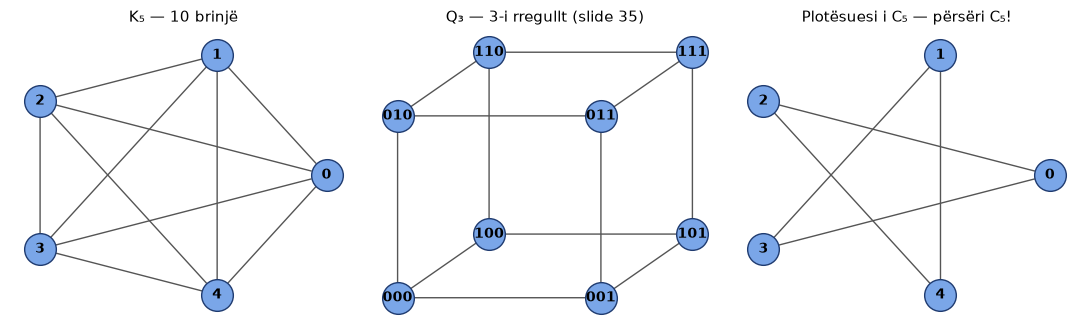

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(11, 3.4))
vizato(set(range(5)), [tuple(e) for e in combinations(range(5), 2)], "K₅ — 10 brinjë", axs[0])
pos_q3 = {v: (int(v[2]) + 0.45 * int(v[0]), int(v[1]) + 0.35 * int(v[0])) for v in Q3_V}
vizato(Q3_V, [tuple(e) for e in Q3_E], "Q₃ — 3-i rregullt (slide 35)", axs[1], pos=pos_q3)
vizato(C5_V, [(i, (i + 2) % 5) for i in range(5)], "Plotësuesi i C₅ — përsëri C₅!", axs[2])
plt.tight_layout(); plt.show()

## Ushtrimi 4 — Nëngrafet, klikat dhe bashkësitë e pavarura (slides 36–40)

Grafi `G` më poshtë ka kulmet e slides 38–40. **Detyra:**
1. `nengraf_i_induktuar(E, W)` — bashkësia e brinjëve të $G[W]$.
2. `eshte_nengraf(VH, EH, VG, EG)` — `True` nëse $H$ është nëngraf i $G$ (kujdes: çdo brinjë e $H$ duhet të ketë skajet në $V(H)$).
3. `eshte_perfshires(VH, EH, VG, EG)` — nëngraf **dhe** me të gjitha kulmet e $G$.
4. `eshte_klike(E, W)` dhe `eshte_e_pavarur(E, W)`.

Në të gjitha, `E` dhe `EH` janë bashkësi `brinje(u, v)`.

In [11]:
VG = set("xzuvaybc")
EG = {brinje(*p) for p in ["xz", "xu", "zu", "zv", "uv", "ua", "va", "vy", "ay", "ab", "yb", "bc"]}


def nengraf_i_induktuar(E, W):
    # PLOTESO: brinjët me të dy skajet në W
    raise NotImplementedError


def eshte_nengraf(VH, EH, VG, EG):
    # PLOTESO
    raise NotImplementedError


def eshte_perfshires(VH, EH, VG, EG):
    # PLOTESO
    raise NotImplementedError


def eshte_klike(E, W):
    # PLOTESO: çdo çift nga W duhet të jetë brinjë
    raise NotImplementedError


def eshte_e_pavarur(E, W):
    # PLOTESO
    raise NotImplementedError

In [12]:
def _testet():
    W = set("xzuvy")
    assert nengraf_i_induktuar(EG, W) == {brinje(*p) for p in ["xz", "xu", "zu", "zv", "uv", "vy"]}, \
        "G[{x,z,u,v,y}] ka 6 brinjë: xz, xu, zu, zv, uv, vy"
    assert eshte_nengraf(W, {brinje("x", "z"), brinje("u", "v")}, VG, EG)
    assert not eshte_nengraf(W, {brinje("x", "v")}, VG, EG), "xv nuk është brinjë e G"
    assert not eshte_nengraf(set("xz"), {brinje("x", "u")}, VG, EG), "brinja xu ka skajin u jashtë V(H)"
    assert eshte_perfshires(VG, {brinje("a", "b")}, VG, EG), "të gjitha kulmet + një brinjë → përfshirës"
    assert not eshte_perfshires(W, nengraf_i_induktuar(EG, W), VG, EG), "i mungojnë kulmet a, b, c"
    assert eshte_klike(EG, set("xzu")) and eshte_klike(EG, set("uva")), "xzu dhe uva janë trekëndësha"
    assert not eshte_klike(EG, set("xzuv")), "x dhe v nuk janë fqinjë"
    assert eshte_e_pavarur(EG, set("xvbc") - {"c"}) and eshte_e_pavarur(EG, set("xac")), "{x,v,b}, {x,a,c} të pavarura"
    assert not eshte_e_pavarur(EG, set("xzc")), "x dhe z janë fqinjë"
    assert eshte_klike(EG, {"x"}) and eshte_e_pavarur(EG, {"x"}), "një kulm i vetëm është edhe klikë edhe i pavarur"

kontrollo("Ushtrimi 4 — Nëngrafet", _testet)

⏳ Ushtrimi 4 — Nëngrafet: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


## Ushtrimi 5 — Paraqitja e grafeve (slides 46–56)

**Matrica e fqinjësisë:** $M[i][j]$ = numri i brinjëve (harqeve) nga kulmi $i$ te kulmi $j$.
Për grafe të padrejtuara është **simetrike**; për multigrafe mund të ketë vlera > 1; për digrafe rreshti
është **origjina** dhe kolona **destinacioni** (slide 49).

**Lista e fqinjësisë:** për çdo kulm, lista e fqinjëve (për digrafe: e pasardhësve).

**Detyra:** plotësoni të dy funksionet. Kulmet renditen sipas `sorted(V)`; brinjët jepen si listë çiftesh
(mund të përsëriten — multigraf). Në këtë ushtrim nuk ka lake.

In [13]:
def matrice_fqinjesie(V, E, drejtuar=False):
    # PLOTESO: indeksi i kulmit v është sorted(V).index(v)
    raise NotImplementedError


def liste_fqinjesie(V, E, drejtuar=False):
    # PLOTESO: fjalor {kulm: [fqinjët në rendin që shfaqen te E]}
    raise NotImplementedError

In [14]:
def _testet():
    V, E = {1, 2, 3, 4}, [(1, 2), (1, 3), (2, 3), (3, 4)]
    assert matrice_fqinjesie(V, E) == [[0, 1, 1, 0], [1, 0, 1, 0], [1, 1, 0, 1], [0, 0, 1, 0]]
    assert liste_fqinjesie(V, E) == {1: [2, 3], 2: [1, 3], 3: [1, 2, 4], 4: [3]}
    M = matrice_fqinjesie(V_konigsberg, E_konigsberg)
    assert M[0][1] == 2 and M[1][0] == 2, "Königsberg: A–B ka 2 ura → M[A][B] = 2"
    assert [sum(r) for r in M] == [5, 3, 3, 3], "shuma e rreshtit = fuqia e kulmit"
    H = [(1, 2), (2, 3), (3, 1), (3, 4), (4, 3)]
    D = matrice_fqinjesie(V, H, drejtuar=True)
    assert D == [[0, 1, 0, 0], [0, 0, 1, 0], [1, 0, 0, 1], [0, 0, 1, 0]], "digraf: rreshti = origjina"
    deg_plus, deg_minus = [sum(r) for r in D], [sum(k) for k in zip(*D)]
    assert sum(deg_plus) == sum(deg_minus) == len(H), "Σ deg⁺ = Σ deg⁻ = |E|"
    assert liste_fqinjesie(V, H, drejtuar=True) == {1: [2], 2: [3], 3: [1, 4], 4: [3]}

kontrollo("Ushtrimi 5 — Paraqitjet", _testet)

⏳ Ushtrimi 5 — Paraqitjet: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


### Kompromiset: graf i dendur apo i rrallë? (slides 54–56)

Matrica ruan gjithmonë $n^2$ numra. Lista ruan $n$ kokë listash + $2\lvert E\rvert$ fqinjë.
Tabela më poshtë llogarit kujtesën për $n = 10\,000$ kulme dhe dendësi të ndryshme.

In [15]:
n = 10_000
max_brinje = n * (n - 1) // 2
print(f"{'Grafi':<34} | {'|E|':>12} | {'dendësia':>8} | {'matrica':>14} | {'lista':>14}")
for emri, m in [("rrjet rrugor (fuqi ≈ 3)", 15_000), ("rrjet social (fuqi ≈ 200)", 1_000_000),
                ("graf i dendur (50% e çifteve)", max_brinje // 2), ("graf i plotë K₁₀₀₀₀", max_brinje)]:
    print(f"{emri:<34} | {m:>12,} | {m / max_brinje:>8.2%} | {n * n:>14,} | {n + 2 * m:>14,}")

Grafi                              |          |E| | dendësia |        matrica |          lista
rrjet rrugor (fuqi ≈ 3)            |       15,000 |    0.03% |    100,000,000 |         40,000
rrjet social (fuqi ≈ 200)          |    1,000,000 |    2.00% |    100,000,000 |      2,010,000
graf i dendur (50% e çifteve)      |   24,997,500 |   50.00% |    100,000,000 |     50,005,000
graf i plotë K₁₀₀₀₀                |   49,995,000 |  100.00% |    100,000,000 |    100,000,000


> **Pyetje (slide 56):** cila paraqitje është më e shpejtë për pyetjen *"a është $\{u,v\}$ brinjë?"* Po për
> *"cilët janë fqinjët e $u$?"* Pse leksioni thotë *"në vijim do të supozojmë se grafi është dhënë me listë fqinjësie"*?

## Ushtrimi 6 — Udhëtim, udha, cikël, shteg, cikël elementar (slides 57–62)

**Detyra:** plotësoni `klasifiko(E, ecja)`. `E` është bashkësia e brinjëve (`brinje(u, v)`), `ecja` është lista e
kulmeve. Ktheni kategorinë **më specifike**:

| Kthe | Kur |
|---|---|
| `"jo udhëtim"` | dy kulme të njëpasnjëshme nuk janë fqinjë |
| `"cikël elementar"` | e mbyllur, pa brinjë të përsëritura, pa kulme të përsëritura (përveç skajeve) |
| `"shteg"` | e hapur, pa kulme të përsëritura |
| `"cikël"` | e mbyllur, pa brinjë të përsëritura (por kulmet përsëriten) |
| `"udha"` | e hapur, pa brinjë të përsëritura (por kulmet përsëriten) |
| `"udhëtim"` | çdo rast tjetër (përsërit brinjë) |

*Kujdes: ecja `["x", "z", "x"]` është e mbyllur dhe nuk përsërit kulme përveç skajeve — por përsërit brinjën xz!*

In [16]:
def klasifiko(E, ecja):
    # PLOTESO
    raise NotImplementedError

In [17]:
def _testet():
    raste = [
        ("x z v a u y".split(), "jo udhëtim"),        # z–v ok, v–a ok, a–u ok, u–y? jo
        ("x z u v a u x".split(), "cikël"),           # e mbyllur, kulmi u përsëritet
        ("x z u v a y".split(), "shteg"),
        ("z u v z".split(), "cikël elementar"),
        ("x z u x".split(), "cikël elementar"),
        ("x z u v z".split(), "udha"),                # z përsëritet, brinjët jo
        ("x z x".split(), "udhëtim"),                 # përsërit brinjën xz
        ("u v a u v".split(), "udhëtim"),             # përsërit brinjën uv
        ("a y b c".split(), "shteg"),
    ]
    for ecja, pritet in raste:
        mori = klasifiko(EG, ecja)
        assert mori == pritet, f"{'-'.join(ecja)}: pritej «{pritet}», u mor «{mori}»"

kontrollo("Ushtrimi 6 — Ecjet", _testet)

⏳ Ushtrimi 6 — Ecjet: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


## Ushtrimi 7 — Largesa, diametri dhe komponentet e lidhura (slides 63–66)

Funksioni `largesat_nga(adj, s)` llogarit largesën nga $s$ te çdo kulm i arritshëm duke eksploruar
grafin "shtresë pas shtrese" (ky është algoritmi **BFS** që do ta studiojmë në Laboratorin 5).
E përdorni si mjet të gatshëm.

**Detyra:**
1. `diametri(adj)` — $\max_{u,v} d(u,v)$; nëse grafi nuk është i lidhur ktheni `float("inf")`.
2. `komponentet(adj)` — lista e komponenteve të lidhura, secila si `set` kulmesh.

In [18]:
from collections import deque

def largesat_nga(adj, s):
    d = {s: 0}
    radha = deque([s])
    while radha:
        u = radha.popleft()
        for v in adj[u]:
            if v not in d:
                d[v] = d[u] + 1
                radha.append(v)
    return d


def adj_nga(V, E):
    adj = {v: set() for v in V}
    for e in E:
        u, v = tuple(e)
        adj[u].add(v); adj[v].add(u)
    return adj


def diametri(adj):
    # PLOTESO: llogaritni largesat nga çdo kulm
    raise NotImplementedError


def komponentet(adj):
    # PLOTESO: kulmet e arritshëm nga një kulm i pavizituar formojnë një komponente
    raise NotImplementedError

In [19]:
def _testet():
    adjG = adj_nga(VG, EG)
    assert largesat_nga(adjG, "x")["c"] == 4, "d(x, c) = 4, p.sh. x–u–a–b–c"
    assert diametri(adjG) == 4, f"diametri i G është 4, u mor {diametri(adjG)}"
    assert diametri(adj_nga(Q3_V, Q3_E)) == 3, "diametri i kubit Q3 është 3"
    assert diametri(adj_nga(set(range(6)), {brinje(u, v) for u, v in combinations(range(6), 2)})) == 1, "diametri i K6 është 1"
    jo_lidhur = adj_nga(set("abcdefg"), {brinje(*p) for p in ["ab", "bc", "de"]})
    assert diametri(jo_lidhur) == float("inf"), "graf jo i lidhur → diametër i pafundëm"
    k = komponentet(jo_lidhur)
    assert sorted(map(sorted, k)) == [["a", "b", "c"], ["d", "e"], ["f"], ["g"]], f"u morën {k}"
    assert len(komponentet(adjG)) == 1, "G është i lidhur: saktësisht një komponente"

kontrollo("Ushtrimi 7 — Largesa, diametri, komponentet", _testet)

⏳ Ushtrimi 7 — Largesa, diametri, komponentet: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


## Ushtrimi 8 — Lidhja te digrafet (slides 72–73)

- **Digraf i lidhur:** zëvendësoni çdo hark me një brinjë (harrojmë drejtimin) — grafi që del është i lidhur.
- **Digraf i lidhur fort:** për çdo dy kulme $u, v$ ka rrugë $u \to v$ **dhe** $v \to u$.
- **Komponentet e lidhura fort (KLF):** nëngrafe të lidhura fort **maksimale**. Dy kulme janë në të njëjtën KLF
  ⟺ secili arrin tjetrin.

**Detyra:** plotësoni tre funksionet. Për arritshmërinë përdorni `largesat_nga` mbi listën e pasardhësve.
(Në Laboratorin 6 do të shihni algoritme më të shpejta për KLF.)

In [20]:
def pasardhesit(V, harqet):
    adj = {v: set() for v in V}
    for u, v in harqet:
        adj[u].add(v)
    return adj


def eshte_i_lidhur(V, harqet):
    # PLOTESO: ndërtoni grafin pa drejtime dhe kontrolloni nëse ka 1 komponente
    raise NotImplementedError


def eshte_i_lidhur_fort(V, harqet):
    # PLOTESO
    raise NotImplementedError


def klf(V, harqet):
    # PLOTESO: gruponi kulmet që arrijnë njëri-tjetrin
    raise NotImplementedError

In [21]:
V8 = set("abcdefgh")
H8 = [("a", "b"), ("b", "c"), ("c", "a"), ("b", "d"), ("d", "e"), ("e", "f"), ("f", "d"),
      ("g", "f"), ("g", "h"), ("h", "g")]

def _testet():
    assert eshte_i_lidhur(V8, H8), "pa drejtime, grafi është i lidhur"
    assert not eshte_i_lidhur_fort(V8, H8), "d nuk arrin a"
    cikli = [("a", "b"), ("b", "c"), ("c", "a")]
    assert eshte_i_lidhur_fort(set("abc"), cikli), "cikli a→b→c→a është i lidhur fort"
    assert not eshte_i_lidhur(set("abcd"), cikli), "d është i izoluar"
    k = sorted(map(sorted, klf(V8, H8)))
    assert k == [["a", "b", "c"], ["d", "e", "f"], ["g", "h"]], f"KLF-të janë abc, def, gh — u morën {k}"
    assert len(klf(set("abcd"), [("a", "b"), ("b", "c"), ("c", "d")])) == 4, "rrugë pa cikle: çdo kulm KLF më vete"

kontrollo("Ushtrimi 8 — Lidhja te digrafet", _testet)

⏳ Ushtrimi 8 — Lidhja te digrafet: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


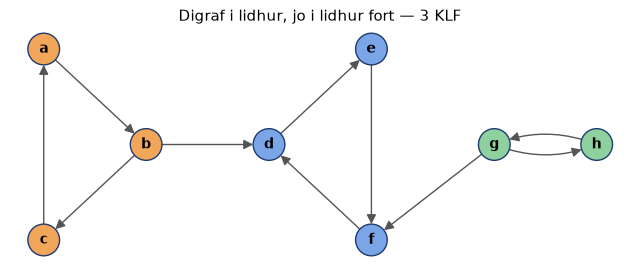

In [22]:
pos8 = {"a": (0, 1), "b": (1, 0.5), "c": (0, 0), "d": (2.2, 0.5), "e": (3.2, 1), "f": (3.2, 0),
        "g": (4.4, 0.5), "h": (5.4, 0.5)}
ngjyra = ["#f2a65a" if v in "abc" else "#7aa6e8" if v in "def" else "#8fd19e" for v in sorted(V8)]
vizato(V8, H8, "Digraf i lidhur, jo i lidhur fort — 3 KLF", drejtuar=True, pos=pos8, ngjyra=ngjyra)
plt.gcf().set_size_inches(8, 3); plt.show()

## Punë në Klasë

**Problemi 1 — Fuqitë.** Për grafin `G` të Ushtrimit 4 (kulmet $x, z, u, v, a, y, b, c$), plotësoni tabelën
e fuqive, verifikoni lemën e shtrëngimit të duarve dhe numëroni kulmet me fuqi tek.

| Kulmi | x | z | u | v | a | y | b | c | Σ |
|---|---|---|---|---|---|---|---|---|---|
| deg | | | | | | | | | |

**Problemi 2 — Grafe speciale.** (a) Sa brinjë ka $K_7$? (b) Vizatoni $\overline{C_5}$ dhe tregoni që është izomorf me $C_5$.
(c) A ekziston graf 3-i rregullt me 7 kulme? Argumentoni me lemën.

**Problemi 3 — Ecjet.** Në grafin `G`, shkruani: një udhëtim që nuk është udha; një udha që nuk është shteg;
një cikël që nuk është cikël elementar; një cikël elementar me gjatësi 4.

**Problemi 4 — Paraqitjet.** Shkruani matricën dhe listën e fqinjësisë për digrafin
$V = \{1,2,3,4\}$, harqet $(1,2), (2,3), (3,1), (3,4), (4,3)$. Gjeni $\deg^+$ dhe $\deg^-$ për çdo kulm.
Sa është $\sum \deg^+$? Pse?

**Problemi 5 — KLF.** Për digrafin e Ushtrimit 8, cili hark i vetëm duhet shtuar që ai të bëhet i lidhur fort?
A ka më shumë se një përgjigje?

## Pyetje Reflektuese

1. Pse Euler mund ta zgjidhte problemin e urave **pa e provuar** asnjë shëtitje? Çfarë roli luan abstraksioni?
2. Lema e shtrëngimit të duarve është kusht i **domosdoshëm** por jo i **mjaftueshëm** për një varg fuqish.
   Shpjegoni me shembullin tuaj nga Ushtrimi 2.
3. Për rrjetin rrugor të Tiranës (slide 11), cilën paraqitje do të zgjidhnit? Po për rrjetin e miqësive në Facebook (slide 13)?
4. Pse *"maksimal"* është fjala kyçe në përkufizimin e komponentes së lidhur?